# 데이터 불러오기

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Dataset path:", path)

100%|██████████| 2.29G/2.29G [00:12<00:00, 195MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2


In [4]:
import torch
import os
from pathlib import Path

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [ ]:
DATA_ROOT = Path("data") 

In [27]:
# train_dir = os.path.join(DATA_ROOT, "chest_xray", "train")
# val_dir = os.path.join(DATA_ROOT, "chest_xray", "val")
# test_dir = os.path.join(DATA_ROOT, "chest_xray", "test")

train_dir = os.path.join(DATA_ROOT, "train")
val_dir = os.path.join(DATA_ROOT, "val")
test_dir = os.path.join(DATA_ROOT, "test")

In [9]:
print(train_dir); print(val_dir); print(test_dir)

data\train
data\val
data\test


In [28]:
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.transforms import v2

transforms = v2.Compose(
    [
        v2.Resize((224, 224)),
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),
    ]
)

# 데이터셋 로드
## ImageFolder는 내부적으로 어떤 폴더에서 이미지를 가져왔는지와 하부 폴더에 라벨을 매겨 기억합니다.
train_dataset = datasets.ImageFolder(train_dir, transform=transforms)
##-- ImageFolder가 폴더명을 스스로 탐색합니다. 
#    이 클래스는 지정된 경로 바로 밑에 있는 서브폴더(하위 폴더)들을 자동으로 검색(Scan)합니다.
#    data/train/ 내부를 조사하여 NORMAL 폴더와 PNEUMONIA 폴더를 스스로 찾아냅니다.
#    폴더 이름을 정렬하여 자동으로 숫자 라벨(labels)을 매깁니다
#    -- NORMAL (N이 P보다 앞서므로) -> 0번 라벨 부여
#    -- PNEUMONIA -> 1번 라벨 부여 
# -- 확인 방법: print(train_dataset.classes) ; print(train_dataset.class_to_idx) ; print(train_dataset.samples[:3]) 

# DataLoader 생성
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 클래스 확인
class_names = train_dataset.classes
print("Class names:", class_names)

Class names: ['NORMAL', 'PNEUMONIA']


In [29]:
print(train_dataset)
print(train_dataset.classes) ; print(train_dataset.class_to_idx) ; print(train_dataset.samples[:3]) 

Dataset ImageFolder
    Number of datapoints: 5216
    Root location: data\train
    StandardTransform
Transform: Compose(
                 Resize(size=[224, 224], interpolation=bilinear, antialias=True)
                 ToImage()
                 ToDtype(scale=True)
           )
['NORMAL', 'PNEUMONIA']
{'NORMAL': 0, 'PNEUMONIA': 1}
[('data\\train\\NORMAL\\IM-0115-0001.jpeg', 0), ('data\\train\\NORMAL\\IM-0117-0001.jpeg', 0), ('data\\train\\NORMAL\\IM-0119-0001.jpeg', 0)]


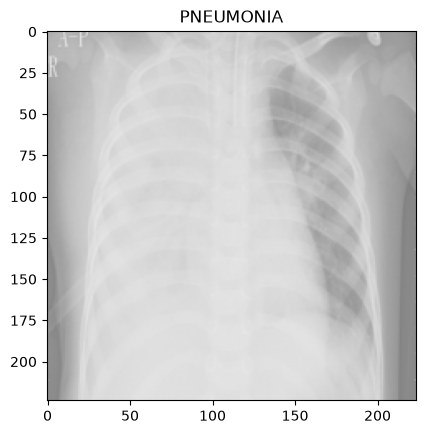

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 로더에서 배치 가져오기 (train)
images, labels = next(iter(train_loader))

# 이미지를 디스플레이
def imshow(img, title):
    img = img / 2 + 0.5  # 정규화 복원
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.show()

# 첫 번째 배치의 첫 번째 이미지 시각화
imshow(images[0], title=class_names[labels[0]])

In [31]:
# 데이터 전처리 정의
data_transforms = {
    'train': v2.Compose([
        v2.Resize((224, 224)),                # 이미지 크기 조정
        v2.RandomCrop((200, 200)),           # 랜덤 크롭 (200x200) - 학습에만 데이터 증강 사용 
        v2.RandomRotation(20),              # 랜덤 회전 (-20도 ~ 20도) - 학습에만 데이터 증강 사용
        v2.ToTensor(),                       # 텐서로 변환
        v2.Normalize([0.5], [0.5])           # 정규화
    ]),
    'val': v2.Compose([
        v2.Resize((224, 224)),               # 이미지 크기 조정
        v2.ToTensor(),                       # 텐서로 변환
        v2.Normalize([0.5], [0.5])           # 정규화
    ]),
    'test': v2.Compose([
        v2.Resize((224, 224)),               # 이미지 크기 조정
        v2.ToTensor(),                       # 텐서로 변환
        v2.Normalize([0.5], [0.5])           # 정규화
    ])
}

c:\Users\dsbang\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [32]:
from torchvision import datasets
from torch.utils.data import DataLoader

# 데이터셋 로드
### ImageFolder클래스는 내부적으로 어떤 폴더에서 이미지를 가져왔는지와 하부 폴더에 라벨을 매겨 기억합니다.
train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
val_dataset = datasets.ImageFolder(val_dir, transform=data_transforms['val'])
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms['test'])

# DataLoader 생성
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

Number of training samples: 5216
Number of validation samples: 16
Number of test samples: 624


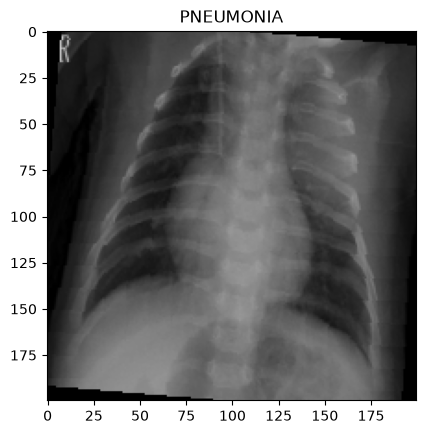

In [33]:
# 데이터 로더에서 배치 가져오기 (train)
images, labels = next(iter(train_loader))

# 이미지를 디스플레이
def imshow(img, title):
    img = img / 2 + 0.5  # 정규화 복원
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.show()

# 첫 번째 배치의 첫 번째 이미지 시각화
imshow(images[0], title=class_names[labels[0]])

# Custom CNN 모델 생성

In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Custom CNN 모델 정의
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)  # Conv2D 입력 채널: 3, 출력 채널: 32
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)                  # MaxPooling
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1) # Conv2D 입력 채널: 32, 출력 채널: 64
        #AdaptiveAvgPool2d 어떤 크기의 입력이 들어오든, 개발자가 설정한 출력 크기(output_size)에 맞춰 내부 커널 크기와 스트라이드를 자동으로 계산(Adaptive)해 줍니다.
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))                       # Adaptive Pooling (7x7) 주요 용도: 입력 크기에 상관없이 '원하는 출력 크기' 고정
        #-- CNN(합성곱 신경망)의 마지막 단계에서는 이미지 특징을 추출한 뒤, 최종 분류를 위해 1차원 벡터로 펼쳐서 Linear 레이어(FC Layer, 완전연결층)에 연결해야 합니다.
        #-- 이때 Linear 레이어는 입력 노드의 개수가 무조건 고정되어 있어야 합니다. 만약 사용자가 모델에 입력하는 이미지 크기(예: 224x224, 512x512 등)가 
        #   바뀐다면 Linear 레이어 바로 직전의 데이터 크기도 바뀌어 에러가 발생하게 됩니다.
        #   이 문제를 해결하기 위해 Linear 레이어 직전에 AdaptiveAvgPool2d(output_size=(1, 1)) 또는 (7, 7) 등을 배치합니다. 
        #   이렇게 하면 어떤 해상도의 이미지가 입력으로 들어와도 Linear 레이어로 들어가는 크기를 항상 일정하게 고정할 수 있어 모델의 유연성이 엄청나게 높아집니다. 
        self.fc1 = nn.Linear(64 * 7 * 7, 128)                             # Fully Connected Layer
        self.fc2 = nn.Linear(128, num_classes)                            # Output Layer

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # Conv1 + Pooling
        x = self.pool(F.relu(self.conv2(x)))  # Conv2 + Pooling
        x = self.avgpool(x)                   # Adaptive Pooling
        x = torch.flatten(x, 1)               # Flattening
        x = F.relu(self.fc1(x))               # Fully Connected Layer 1
        x = self.fc2(x)                       # Output Layer
        return x

# 클래스 수 설정 (NORMAL, PNEUMONIA)
num_classes = len(class_names)

# 모델 학습 및 평가 함수 선언

In [35]:
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    step = 0
    for epoch in range(num_epochs):
        model.train()  # 모델을 학습 모드로 설정
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            # 데이터를 GPU/CPU로 이동
            inputs, labels = inputs.to(device), labels.to(device)

            # 이전 그래디언트 초기화
            optimizer.zero_grad()

            # Forward Pass
            outputs = model(inputs)

            # 손실 계산
            loss = criterion(outputs, labels)
            loss.backward()  # Backward Pass

            # 가중치 업데이트
            optimizer.step()

            running_loss += loss.item()

            # 정확도 계산
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            step += 1

        # 학습 손실 및 정확도 출력
        avg_train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # 검증 단계 수행
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

In [36]:
def evaluate(model, dataloader, loss_fn):
    model.eval()

    losses = []  # 손실값을 저장할 리스트
    correct = 0  # 올바르게 예측한 샘플 수
    total = 0    # 전체 샘플 수

    with torch.no_grad():
        for inputs, labels in dataloader:
            # 데이터를 GPU 또는 CPU로 이동
            inputs, labels = inputs.to(device), labels.to(device)

            # 모델의 예측값 계산
            outputs = model(inputs)

            # 손실값 계산
            loss = loss_fn(outputs, labels)
            losses.append(loss.item())

            # 예측값 가져오기
            pred_labels = torch.argmax(outputs, dim=1)  # [배치 크기]
            correct += (pred_labels == labels).sum().item()
            total += labels.size(0)

    # 평균 손실값과 정확도 계산
    avg_loss = sum(losses) / len(losses)
    accuracy = correct / total

    return avg_loss, accuracy

In [37]:
import torch.optim as optim

model = CustomCNN(num_classes).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [20]:
train(model, train_loader, val_loader, loss_fn, optimizer, num_epochs=10)

Epoch 1/10, Train Loss: 0.3326, Train Acc: 0.8528, Val Loss: 0.7732, Val Acc: 0.5625
Epoch 2/10, Train Loss: 0.2202, Train Acc: 0.9095, Val Loss: 0.9100, Val Acc: 0.6250
Epoch 3/10, Train Loss: 0.1965, Train Acc: 0.9222, Val Loss: 0.5117, Val Acc: 0.7500
Epoch 4/10, Train Loss: 0.1695, Train Acc: 0.9350, Val Loss: 1.0362, Val Acc: 0.5625
Epoch 5/10, Train Loss: 0.1495, Train Acc: 0.9408, Val Loss: 0.9421, Val Acc: 0.6875
Epoch 6/10, Train Loss: 0.1355, Train Acc: 0.9469, Val Loss: 0.9430, Val Acc: 0.6875
Epoch 7/10, Train Loss: 0.1323, Train Acc: 0.9477, Val Loss: 0.6219, Val Acc: 0.6250
Epoch 8/10, Train Loss: 0.1341, Train Acc: 0.9505, Val Loss: 1.1240, Val Acc: 0.6875
Epoch 9/10, Train Loss: 0.1209, Train Acc: 0.9530, Val Loss: 0.6779, Val Acc: 0.6250
Epoch 10/10, Train Loss: 0.1144, Train Acc: 0.9561, Val Loss: 0.7516, Val Acc: 0.6250


In [21]:
test_loss, test_acc = evaluate(model, test_loader, loss_fn)
test_acc

0.8878205128205128

# Transfer Learning ( 기존 가중치 동결 - Tuning 없음)

In [23]:
import torchvision.models as models

# Pretrained ResNet 모델 로드
pretrained_model = models.resnet18(pretrained=True)


In [ ]:

# Feature Extractor 동결 (파라미터 업데이트 불가)
for param in pretrained_model.parameters():
    param.requires_grad = False

# Classifier 교체 (기존 Fully Connected Layer를 새로운 Classifier로 교체)
num_features = pretrained_model.fc.in_features  # 기존 학습 모델의 입력 1,000 Fully Connected Layer 입력 크기 저장 
pretrained_model.fc = nn.Linear(num_features, num_classes)  # 새 출력층 생성 - 마지막 층의 출력을 2진분류 위해 변경
pretrained_model = pretrained_model.to(device)

c:\Users\dsbang\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\dsbang\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\dsbang/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 44.7MB/s]


In [24]:
print(pretrained_model.fc.weight.device)

cpu


In [38]:
# 손실 함수와 Optimizer 설정
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 학습 실행
train(pretrained_model, train_loader, val_loader, loss_fn, optimizer, num_epochs=10)

# 테스트 실행
evaluate(pretrained_model, test_loader, loss_fn)

Epoch 1/10, Train Loss: 8.8933, Train Acc: 0.0000, Val Loss: 15.5925, Val Acc: 0.0000
Epoch 2/10, Train Loss: 8.8939, Train Acc: 0.0000, Val Loss: 15.3978, Val Acc: 0.0000
Epoch 3/10, Train Loss: 8.8913, Train Acc: 0.0000, Val Loss: 15.6357, Val Acc: 0.0000
Epoch 4/10, Train Loss: 8.8785, Train Acc: 0.0000, Val Loss: 15.4394, Val Acc: 0.0000
Epoch 5/10, Train Loss: 8.8912, Train Acc: 0.0000, Val Loss: 15.6198, Val Acc: 0.0000
Epoch 6/10, Train Loss: 8.9078, Train Acc: 0.0000, Val Loss: 15.4615, Val Acc: 0.0000
Epoch 7/10, Train Loss: 8.8889, Train Acc: 0.0000, Val Loss: 15.4925, Val Acc: 0.0000
Epoch 8/10, Train Loss: 8.8896, Train Acc: 0.0000, Val Loss: 15.6192, Val Acc: 0.0000
Epoch 9/10, Train Loss: 8.8850, Train Acc: 0.0000, Val Loss: 15.6237, Val Acc: 0.0000
Epoch 10/10, Train Loss: 8.8819, Train Acc: 0.0002, Val Loss: 15.4721, Val Acc: 0.0000


(14.181116962432862, 0.0)

# Transfer Learning (Partial Fine-Tuning)

In [ ]:
pretrained_model.la

In [39]:
# Pretrained ResNet 모델 로드
pretrained_model = models.resnet18(pretrained=True)

# Feature Extractor의 초기 층 동결
for name, param in pretrained_model.named_parameters():
    if "layer4" in name or "fc" in name:  # ResNet의 마지막 블록(layer4)와 Fully Connected Layer만 학습 가능
        param.requires_grad = True
    else:
        param.requires_grad = False

# Classifier 교체
num_features = pretrained_model.fc.in_features  # 기존 Fully Connected Layer 입력 크기
pretrained_model.fc = nn.Linear(num_features, num_classes)  # 새 출력층 생성

print("Trainable parameters:")
for name, param in pretrained_model.named_parameters():
    if param.requires_grad:
        print(name)

pretrained_model = pretrained_model.to(device)

c:\Users\dsbang\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\dsbang\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Trainable parameters:
layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
fc.weight
fc.bias


In [40]:
# 손실 함수와 Optimizer 설정
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 학습 실행
train(pretrained_model, train_loader, val_loader, loss_fn, optimizer, num_epochs=10)

# 테스트 실행
evaluate(pretrained_model, test_loader, loss_fn)

Epoch 1/10, Train Loss: 0.7785, Train Acc: 0.3760, Val Loss: 0.8152, Val Acc: 0.5625
Epoch 2/10, Train Loss: 0.7843, Train Acc: 0.3700, Val Loss: 0.8129, Val Acc: 0.5625
Epoch 3/10, Train Loss: 0.7813, Train Acc: 0.3809, Val Loss: 0.8188, Val Acc: 0.5625
Epoch 4/10, Train Loss: 0.7773, Train Acc: 0.3848, Val Loss: 0.8135, Val Acc: 0.5625
Epoch 5/10, Train Loss: 0.7773, Train Acc: 0.3806, Val Loss: 0.8148, Val Acc: 0.5625
Epoch 6/10, Train Loss: 0.7837, Train Acc: 0.3702, Val Loss: 0.8198, Val Acc: 0.5625
Epoch 7/10, Train Loss: 0.7784, Train Acc: 0.3819, Val Loss: 0.8210, Val Acc: 0.5625
Epoch 8/10, Train Loss: 0.7849, Train Acc: 0.3671, Val Loss: 0.8257, Val Acc: 0.5625
Epoch 9/10, Train Loss: 0.7808, Train Acc: 0.3765, Val Loss: 0.8172, Val Acc: 0.5625
Epoch 10/10, Train Loss: 0.7791, Train Acc: 0.3760, Val Loss: 0.8196, Val Acc: 0.5625


(0.8198234677314759, 0.41346153846153844)

# Transfer Learning (Full Fine-Tuning)

In [41]:
# Pretrained ResNet 모델 로드
pretrained_model = models.resnet18(pretrained=True)

# 모든 층 학습 가능하도록 설정
for param in pretrained_model.parameters():
    param.requires_grad = True

# Classifier 교체
num_features = pretrained_model.fc.in_features  # 기존 Fully Connected Layer 입력 크기
pretrained_model.fc = nn.Linear(num_features, num_classes)  # 새 출력층 생성
pretrained_model = pretrained_model.to(device)

c:\Users\dsbang\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\dsbang\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [42]:
# 손실 함수와 Optimizer 설정
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(pretrained_model.parameters(), lr=0.00001)  # Full Fine-Tuning에서는 더 낮은 학습률

In [43]:
# 학습 실행
train(pretrained_model, train_loader, val_loader, loss_fn, optimizer, num_epochs=10)

# 테스트 실행
evaluate(pretrained_model, test_loader, loss_fn)

Epoch 1/10, Train Loss: 0.2342, Train Acc: 0.9135, Val Loss: 0.2196, Val Acc: 0.9375
Epoch 2/10, Train Loss: 0.1038, Train Acc: 0.9668, Val Loss: 0.2399, Val Acc: 0.8750
Epoch 3/10, Train Loss: 0.0858, Train Acc: 0.9707, Val Loss: 0.2956, Val Acc: 0.8125
Epoch 4/10, Train Loss: 0.0732, Train Acc: 0.9751, Val Loss: 0.2708, Val Acc: 0.8125
Epoch 5/10, Train Loss: 0.0640, Train Acc: 0.9787, Val Loss: 0.1975, Val Acc: 0.8750
Epoch 6/10, Train Loss: 0.0587, Train Acc: 0.9789, Val Loss: 0.1467, Val Acc: 0.9375
Epoch 7/10, Train Loss: 0.0519, Train Acc: 0.9824, Val Loss: 0.1475, Val Acc: 0.9375
Epoch 8/10, Train Loss: 0.0478, Train Acc: 0.9843, Val Loss: 0.0623, Val Acc: 1.0000
Epoch 9/10, Train Loss: 0.0395, Train Acc: 0.9873, Val Loss: 0.1081, Val Acc: 1.0000
Epoch 10/10, Train Loss: 0.0399, Train Acc: 0.9860, Val Loss: 0.0711, Val Acc: 1.0000


(0.37630541692487895, 0.8894230769230769)